### Problem Statement: 
In the banking and financial services industry, accurate loan approval is critical to reduce credit risk and improve lending efficiency. Traditional approval processes are often manual and rule-based, making it difficult to quickly identify high-risk applicants. The client needs a data-driven predictive system to support smarter and faster loan approval decisions. 

#### Import Libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns",None)

#### Load Dataset

In [2]:
train=pd.read_csv(r"C:\Users\SAHITHI VITTAL\Downloads\Test\Test\train.csv")
test=pd.read_csv(r"C:\Users\SAHITHI VITTAL\Downloads\Test\Test\test.csv")

### Understand the data

In [3]:
train.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [4]:
# shape:
train.shape,test.shape

((35999, 14), (9001, 14))

* **Train Data:**
>* No of Rows:35999
>* No. of Columns : 14
* **Test Data:**
>* No of Rows: 9001
>* No. of Columns : 14

#data types
train.info()

* Dataset contains 35,999 loan records and 14 features.
* No missing values were found.
* Dataset includes customer demographics, financial information, credit history, and loan details.

In [5]:
#check null values
train.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

* Data does not have null values

In [6]:
#duplicates
train[train.duplicated()]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status


* Data does not have anu duplicate records

In [7]:
#statistical summary
train.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,35999.000000,3.599900e+04,35999.000000,35999.000000,35999.000000,35999.000000,35999.000000,35999.000000,35999.00000
mean,27.756104,8.078450e+04,5.492708,9547.586572,10.962231,0.137667,5.836412,632.813995,0.19745
std,6.257207,7.377958e+04,6.261994,6285.654364,3.021927,0.085669,4.007652,50.456070,0.39808
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.00000
25%,23.000000,4.787750e+04,1.000000,5000.000000,8.490000,0.070000,3.000000,602.000000,0.00000
50%,26.000000,6.754500e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.00000
75%,30.000000,9.682450e+04,8.000000,12000.000000,12.990000,0.190000,8.000000,670.000000,0.00000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.00000


* Most applicants are young adults, with an average age of 28 years.
* The average income of applicants is around 80,785.
* The average loan amount is 9,548 with an average interest rate of 10.96%.
* The average credit score is 633, indicating moderate creditworthiness among borrowers.
* About 20% of the loans belong to the positive loan_status category.
* Extreme values in age (144 years), income, and employment experience suggest potential outliers that require further investigation.

### Target Varaiable Analysis

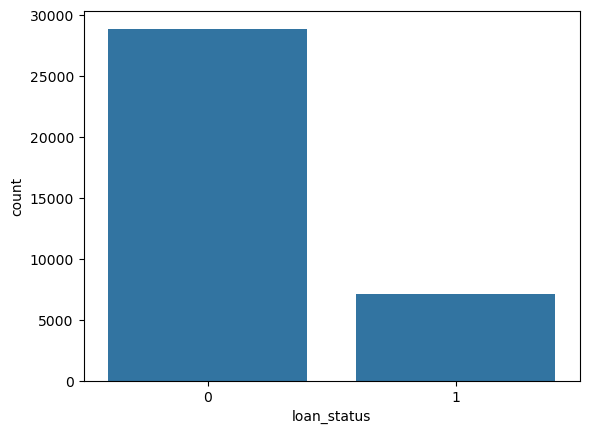

In [8]:
#class distribution
sns.countplot(x=train['loan_status'],data=train)
plt.show()

In [9]:
#percentage distribution
train['loan_status'].value_counts(normalize=True)*100

loan_status
0    80.255007
1    19.744993
Name: proportion, dtype: float64

* Approximately 20% of applicants belong to the default class.
* The dataset is moderately imbalanced, with most applicants not defaulting.

### Univariate Analysis

Understand Variable Distributions

In [10]:
#Numerical
num_cols=train.select_dtypes(include=np.number).columns
len(num_cols)

9

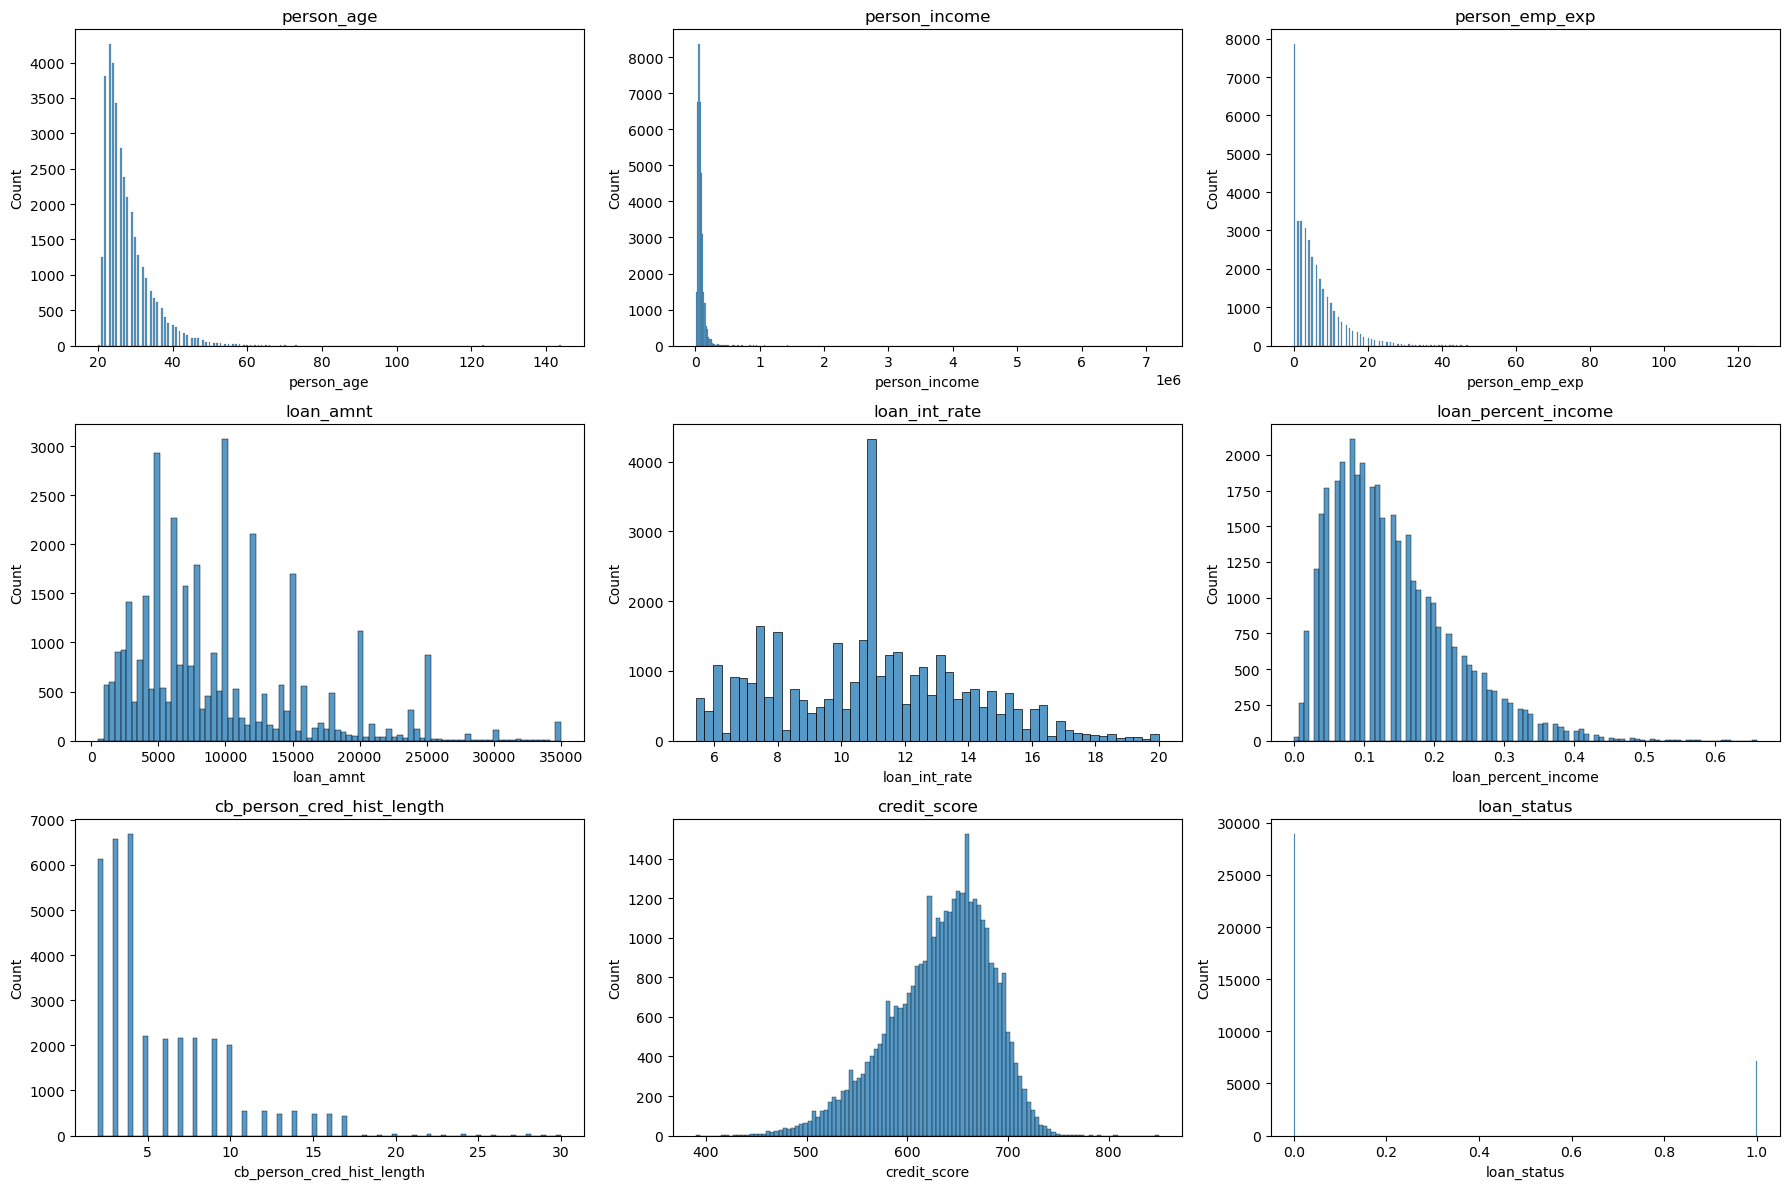

In [11]:
nrows=3
ncols=3
iterator=1

plt.figure(figsize=(18,12))
for i in num_cols:
    plt.subplot(nrows,ncols,iterator)
    sns.histplot(x=train[i])
    plt.title(i)
    iterator+=1

plt.tight_layout()
plt.show()

* Insights :
> * Most borrowers are between 20 and 35 years old.
> * Most applicants fall in lower to middle income ranges.
> * Most loans are concentrated in lower loan amount ranges.Only a small proportion of customers apply for large loans.
> * Most borrowers have credit scores in the fair-to-good range.

<function matplotlib.pyplot.show(close=None, block=None)>

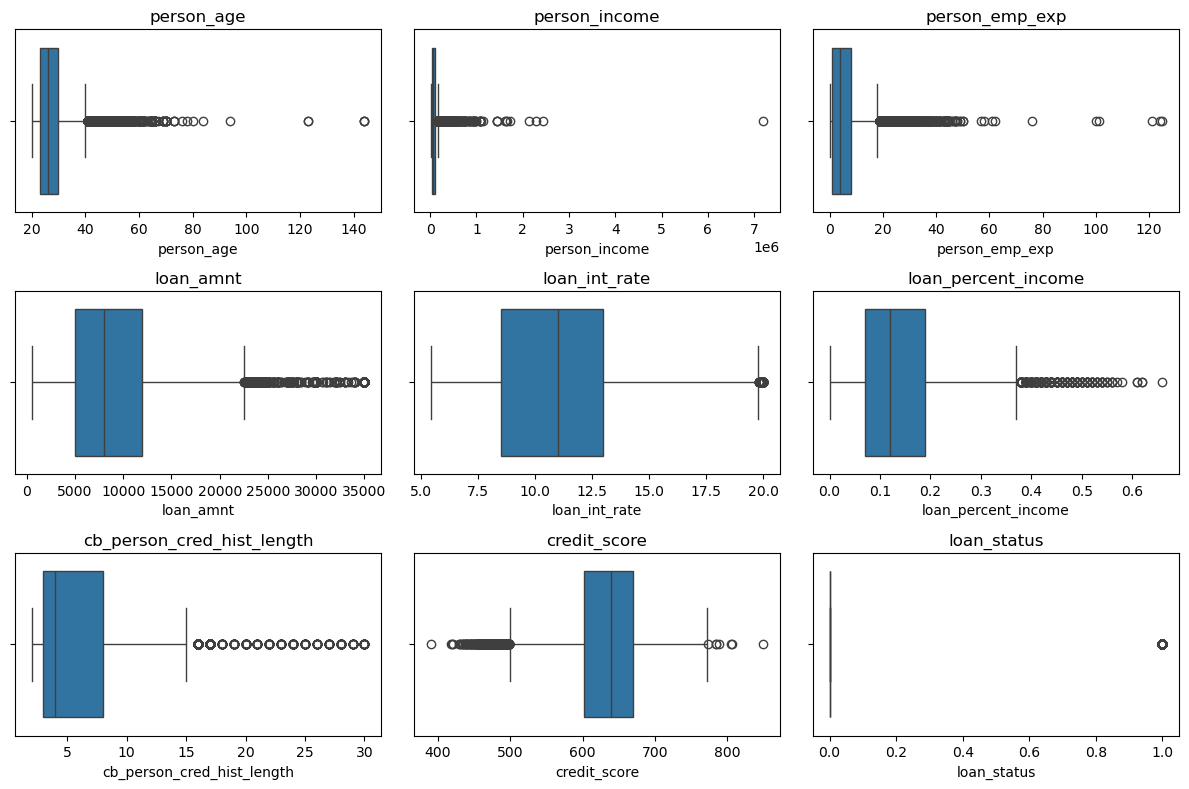

In [12]:
nrows=3
ncols=3
iterator=1

plt.figure(figsize=(12,8))
for i in num_cols:
    plt.subplot(nrows,ncols,iterator)
    sns.boxplot(x=train[i])
    plt.title(i)
    iterator+=1

plt.tight_layout()
plt.show
   

* Insights:
>* Several variables contain extreme values, particularly age, income, and employment experience, indicating the presence of potential outliers.

In [13]:
cat_cols=train.select_dtypes(exclude=np.number).columns
len(cat_cols)

5

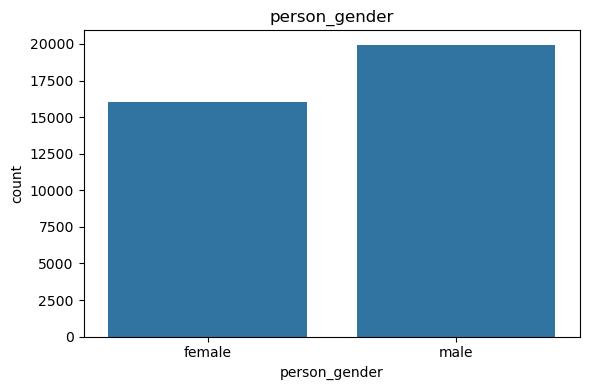

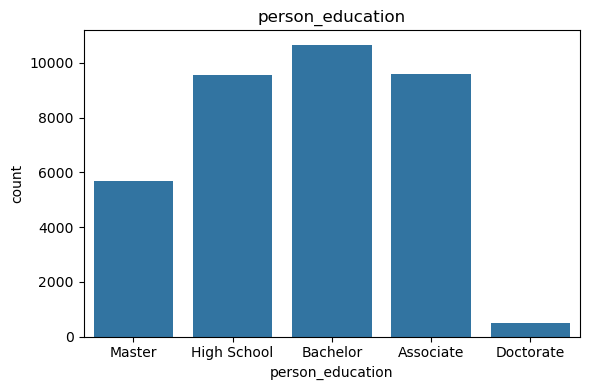

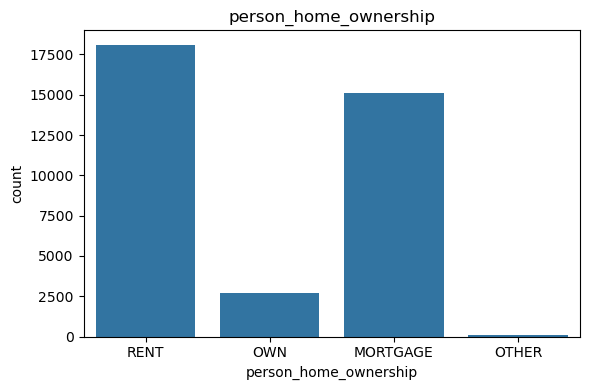

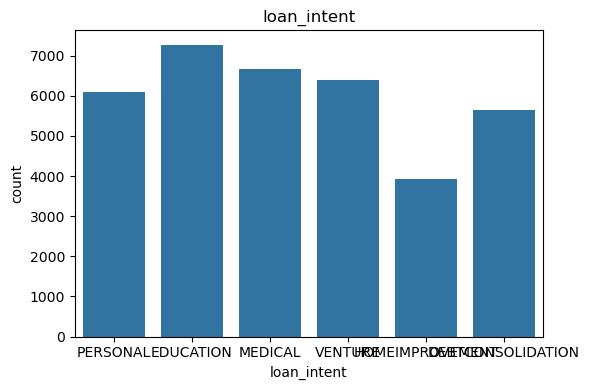

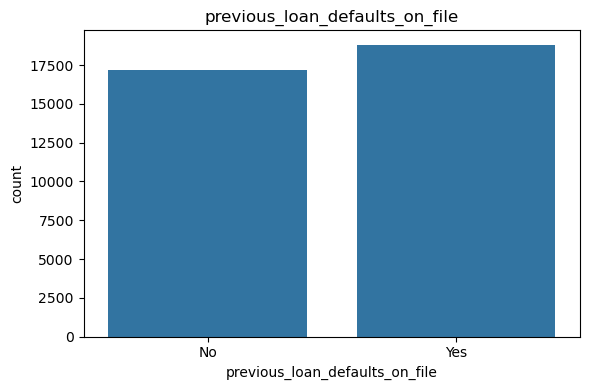

In [14]:
#categorical
nrows=3
ncols=2
iterator=1
for i in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=train[i])
    plt.title(i)
    plt.tight_layout()
    plt.show()

* Insights:
>* The dataset contains both male and female applicants, with one group forming a larger share of borrowers.
>* Certain education levels are more common among loan applicants than others
>* Most applicants belong to a few dominant home ownership categories.
>* Loan applications are distributed across multiple purposes, with some loan intents being more common.
>* Most applicants do not have a previous loan default on file.

### Bivariate Analysis

In [15]:
num_cols=num_cols = train[['person_age', 'person_income', 'person_emp_exp',
                  'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                  'cb_person_cred_hist_length', 'credit_score']]

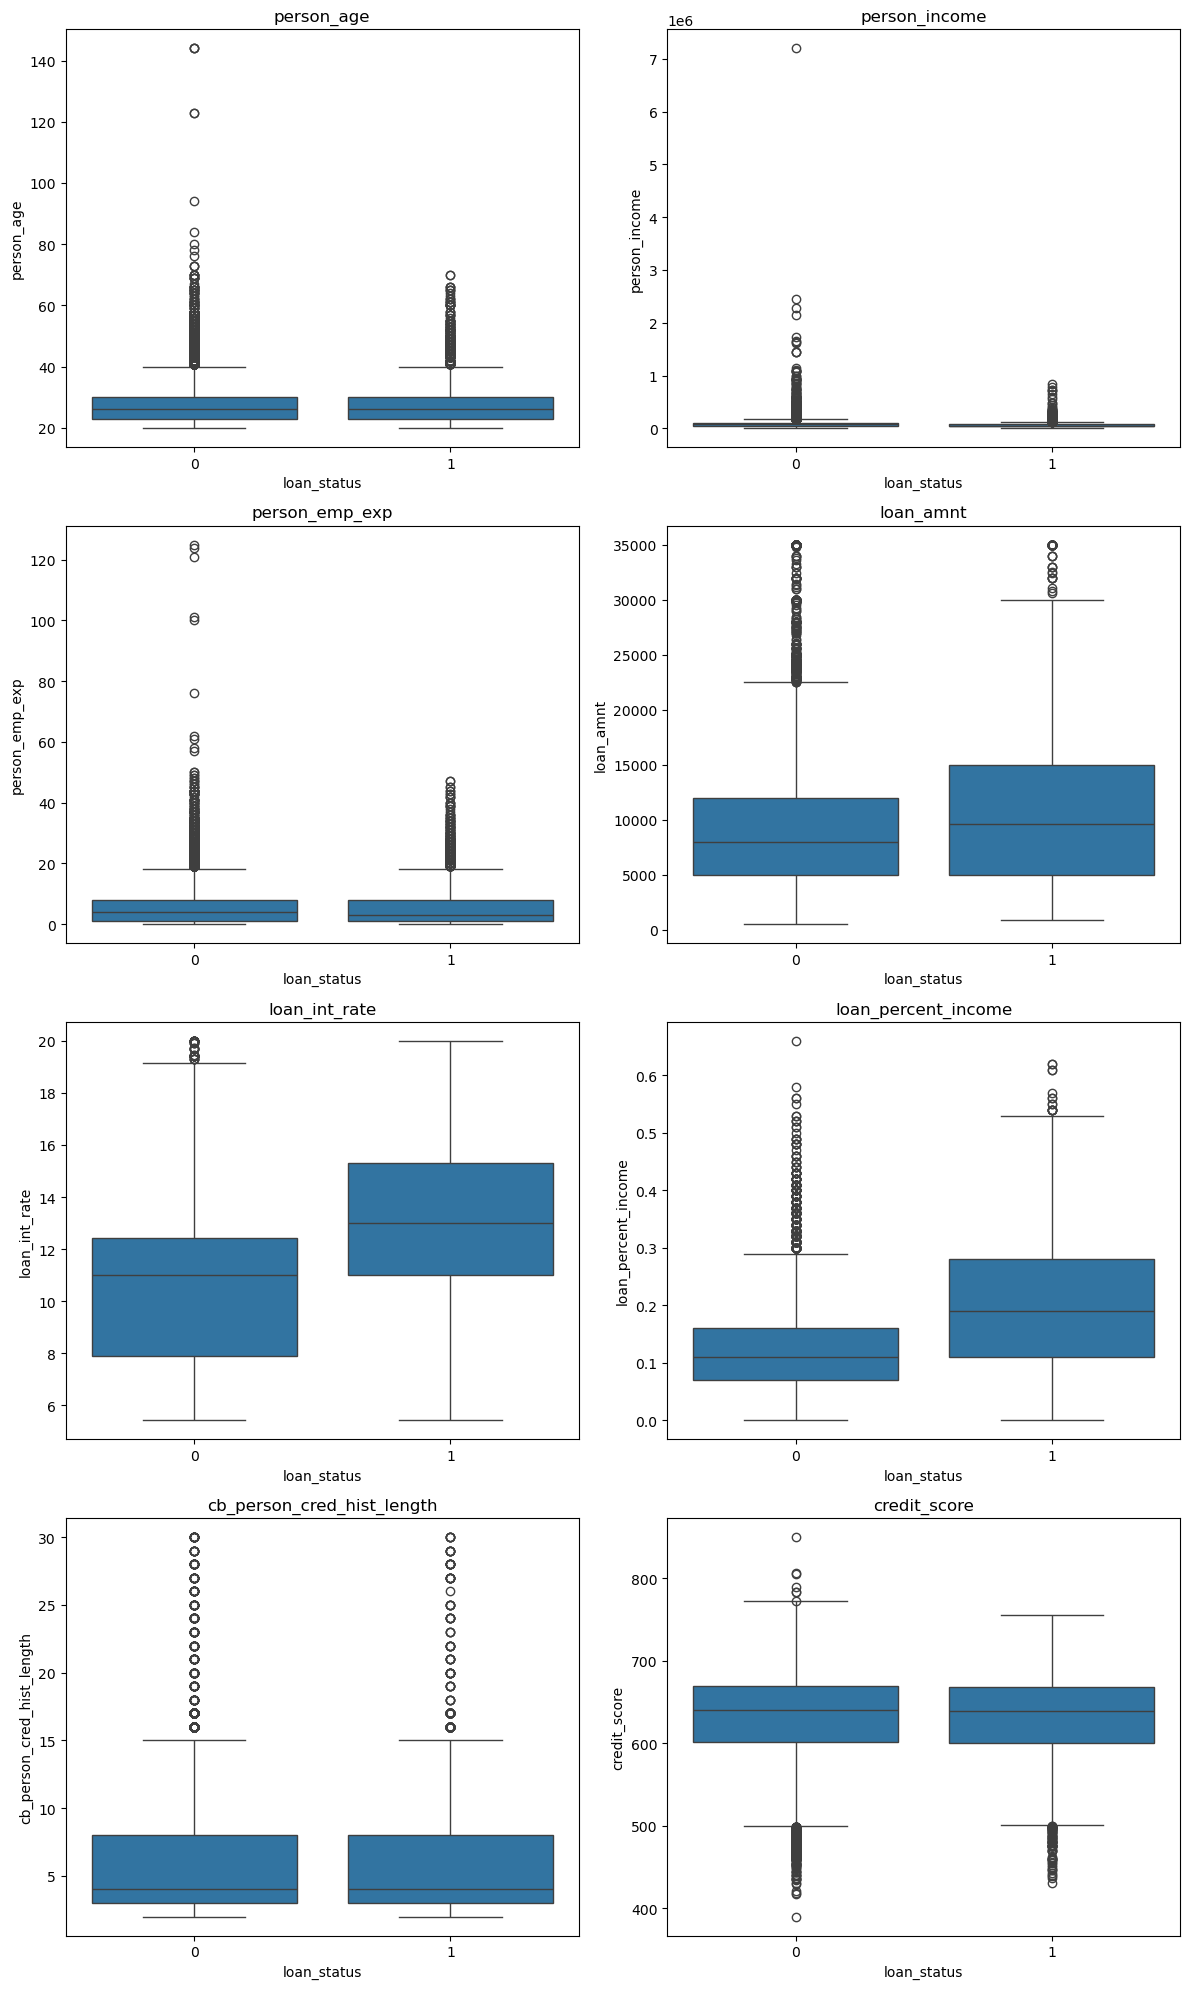

In [16]:
#numerical vs target variable
nrows=4
ncols=2
iterator=1

plt.figure(figsize=(12,20))

for i in num_cols:
    plt.subplot(nrows,ncols,iterator)
    sns.boxplot(x=train['loan_status'],y=i,data=train)
    plt.title(i)
    iterator+=1

plt.tight_layout()
plt.show()
   

In [17]:
cat_cols

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')

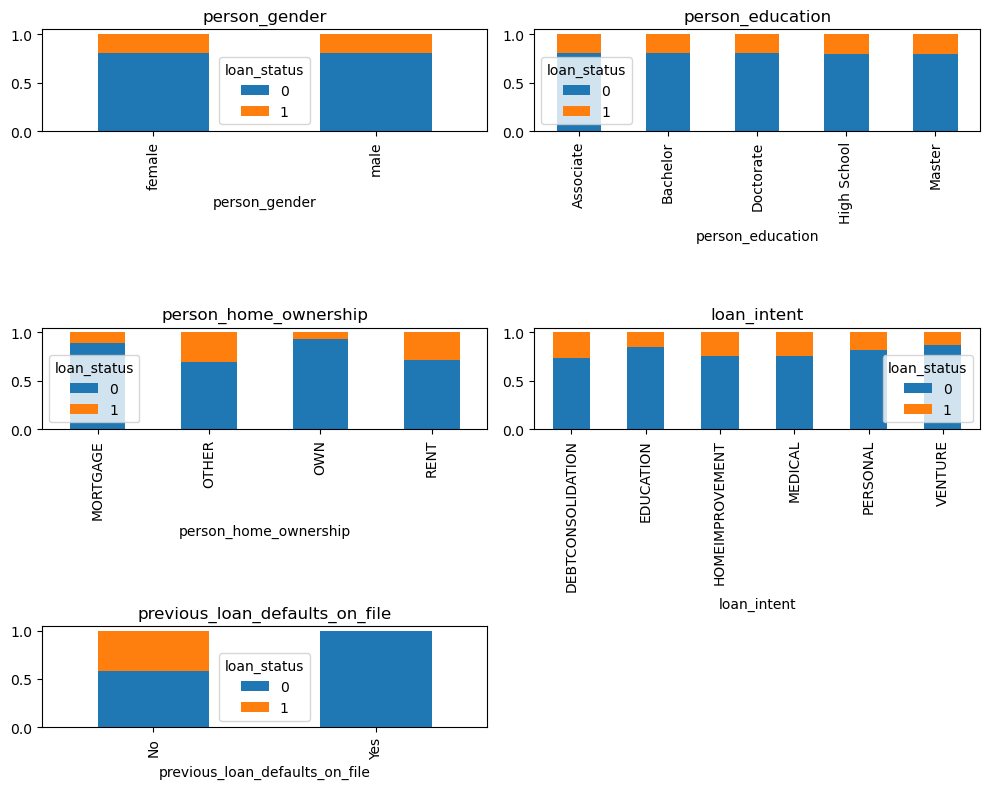

In [18]:
# categorical vs target
nrows = 3
ncols = 2
iterator = 1

plt.figure(figsize=(10,8))

for i in cat_cols:
    plt.subplot(nrows, ncols, iterator)
    pd.crosstab(train[i],train['loan_status'],normalize='index'
               ).plot(kind='bar',stacked=True,ax=plt.gca())
    plt.title(i)
    plt.legend(title='loan_status')
    iterator += 1

plt.tight_layout()
plt.show()

#Self-employed customers exhibit a higher default rate than salaried customers

*Insights:
>* Default rates appear relatively similar across gender categories.
>* Some education groups show higher default proportions than others.
>* Loan repayment behavior varies across home ownership categories.
>* Certain loan purposes are associated with higher default rates.
>* Applicants with previous defaults show a noticeably higher default rate.


### correlation Analysis

In [19]:
num_cols =train.select_dtypes(include=np.number).columns

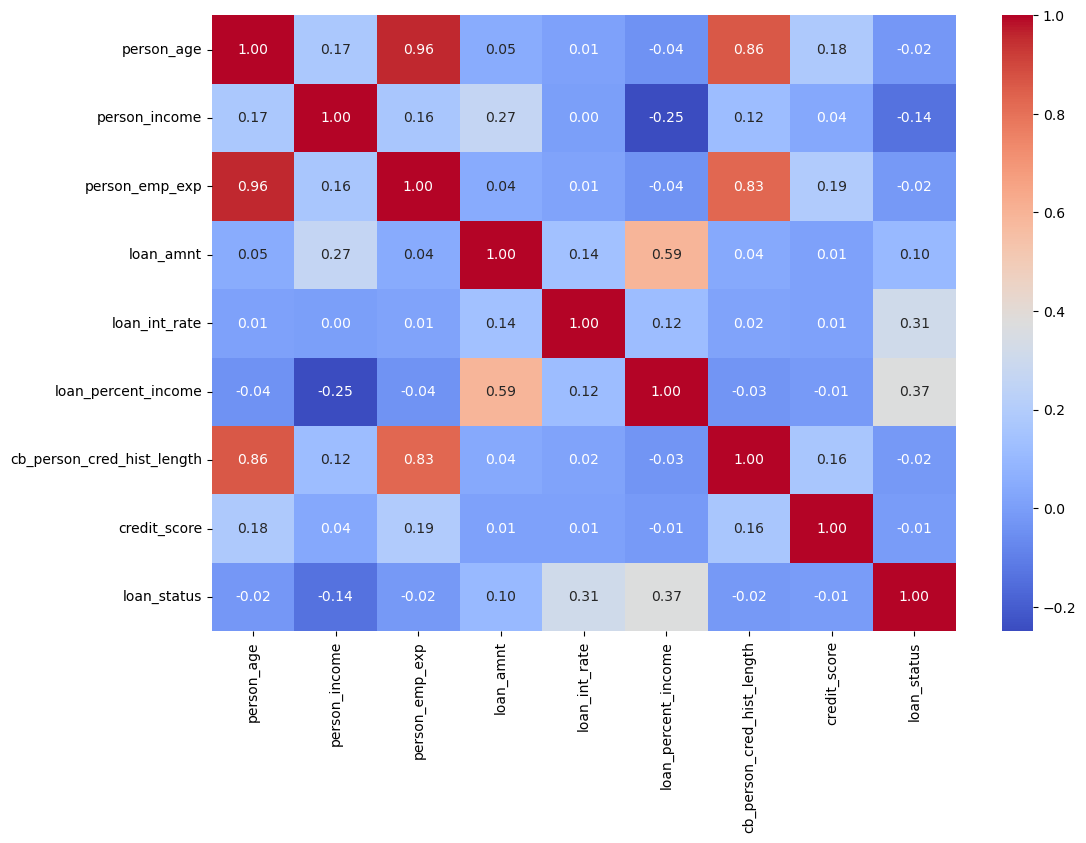

In [20]:
corr=train[num_cols].corr()
plt.figure(figsize=(12,8))

sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

* Insight:
>* Most numerical variables show weak to moderate correlations.
>* No severe multicollinearity is observed.
>* Credit-related variables show meaningful relationships with loan outcomes.

### Statistical Test

In [21]:
num_cols=train.select_dtypes(include=np.number).columns

In [22]:
from scipy.stats import mannwhitneyu
results=[]

for col in num_cols:
    default=train[train['loan_status']==1][col].dropna()
    non_default=train[train['loan_status']==0][col].dropna()
    stat,p_val = mannwhitneyu(default,non_default,alternative='two-sided')

    results.append([col,
        stat,
        p_val,
        "Significant" if p_val < 0.05 else "Not Significant"
    ])

mw_results = pd.DataFrame(
    results,
    columns=["Feature", "Statistic", "P_Value", "Result"]
)

mw_results.sort_values("P_Value")

,Feature,Statistic,P_Value,Result
1,person_income,63705802.5,0.000000e+00,Significant
4,loan_int_rate,145715809.0,0.000000e+00,Significant
5,loan_percent_income,148402746.0,0.000000e+00,Significant
8,loan_status,205357228.0,0.000000e+00,Significant
3,loan_amnt,114812330.5,5.503531e-54,Significant
0,person_age,96942090.0,2.266030e-13,Significant
6,cb_person_cred_hist_length,97779483.0,2.961284e-10,Significant
2,person_emp_exp,98551259.5,1.192016e-07,Significant
7,credit_score,101039810.5,3.680244e-02,Significant


* Most numerical variables showed statistically significant differences between default and non-default borrowers, indicating their usefulness in predicting loan outcomes.

In [23]:
#categorical vs target variable
from scipy.stats import chi2_contingency

results=[]

for col in cat_cols:
    contingency_table=pd.crosstab(train[col],train['loan_status'])
    chi2, p_val,dof,expected=chi2_contingency(contingency_table)
    
    results.append([col,chi2,p_val,
    "Significant" if p_val < 0.05 else "Not Significant"])

chi_results = pd.DataFrame(results,columns=["Feature", "Chi2", "P_Value", "Result"])

chi_results.sort_values("P_Value")  

,Feature,Chi2,P_Value,Result
2,person_home_ownership,1892.755149,0.000000e+00,Significant
4,previous_loan_defaults_on_file,9681.842346,0.000000e+00,Significant
3,loan_intent,561.458011,4.286030e-119,Significant
1,person_education,3.503065,4.774125e-01,Not Significant
0,person_gender,0.006987,9.333860e-01,Not Significant


* Most categorical variables showed a significant relationship with loan status, suggesting that borrower characteristics influence default behavior.

### Feature Engineering

In [24]:
train.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [25]:
# loan Income Ratio
train['loan_income_ratio'] = train['loan_amnt'] / train['person_income']
test['loan_income_ratio'] = test['loan_amnt'] / test['person_income']

* The loan-to-income Ratio was created to measure repayment burden. Higher values indicate a larger financial burden relative to income.

In [26]:
#Income Group
train['income_group'] = pd.qcut(train['person_income'],q=4,
    labels=['Low', 'Medium', 'High', 'Very High'])

test['income_group'] = pd.qcut(test['person_income'],q=4,
    labels=['Low', 'Medium', 'High', 'Very High'])

* Created to categorize borrowers by income level and identify differences in default behavior across income segments.

In [27]:
#Credit Category
train['credit_category'] = pd.cut(train['credit_score'],
    bins=[300, 580, 670, 740, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent'])

test['credit_category'] = pd.cut(
    test['credit_score'],
    bins=[300, 580, 670, 740, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent'])

* Created credit_category was created  because Credit score bands are more interpretable than raw scores.

In [28]:
#Employment Experience Group
train['experience_group'] = pd.cut(train['person_emp_exp'],
    bins=[0, 2, 5, 10, 100],
    labels=['New', 'Junior', 'Mid', 'Experienced'])

test['experience_group'] = pd.cut(test['person_emp_exp'],
    bins=[0, 2, 5, 10, 100],
    labels=['New', 'Junior', 'Mid', 'Experienced'])

* Created to group borrowers based on work experience and analyze whether employment stability impacts loan default risk.

In [29]:
#Previous Default Flag
train['has_previous_default'] = (train['previous_loan_defaults_on_file'] == 'Yes').astype(int)
test['has_previous_default'] = (test['previous_loan_defaults_on_file'] == 'Yes').astype(int)

Created to identify borrowers with past loan defaults, as previous repayment behavior can indicate future credit risk.

### Encoding

In [30]:
train=pd.get_dummies(train,drop_first=True)
test=pd.get_dummies(test,drop_first=True)

In [31]:
train,test= train.align(test,join='left',axis=1,fill_value=0)

### Split Data

In [32]:
X = train.drop('loan_status',axis=1)
y=train['loan_status']

### train Validation Split

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Base Model

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report

In [35]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=100)
lr.fit(X_train, y_train)
lr_pred=lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test,lr_pred))
print(classification_report(y_test,lr_pred))

Accuracy: 0.85875
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5760
           1       0.71      0.50      0.58      1440

    accuracy                           0.86      7200
   macro avg       0.80      0.72      0.75      7200
weighted avg       0.85      0.86      0.85      7200



C:\Users\SAHITHI VITTAL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9298611111111111
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      5760
           1       0.90      0.73      0.81      1440

    accuracy                           0.93      7200
   macro avg       0.92      0.86      0.88      7200
weighted avg       0.93      0.93      0.93      7200



In [37]:
xgb = XGBClassifier(random_state=42,eval_metric='logloss')

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.9356944444444445
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      5760
           1       0.89      0.78      0.83      1440

    accuracy                           0.94      7200
   macro avg       0.92      0.88      0.89      7200
weighted avg       0.93      0.94      0.93      7200



### Compare Models

In [38]:
results = pd.DataFrame({'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)]})

results.sort_values('Accuracy', ascending=False)

,Model,Accuracy
2,XGBoost,0.935694
1,Random Forest,0.929861
0,Logistic Regression,0.858750


* Insight:
>* XGBoost achieved the best overall performance and was selected as the final model.

### Feature Importance (for RF or XGBoost)

In [39]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_})

top_features = feature_importance.sort_values('Importance',ascending=False).head(10)

print(top_features)

                        Feature  Importance
9          has_previous_default    0.792042
16    person_home_ownership_OWN    0.023850
17   person_home_ownership_RENT    0.023292
8             loan_income_ratio    0.022443
22          loan_intent_VENTURE    0.019919
4                 loan_int_rate    0.016740
19  loan_intent_HOMEIMPROVEMENT    0.013176
1                 person_income    0.010280
18        loan_intent_EDUCATION    0.007859
21         loan_intent_PERSONAL    0.006917


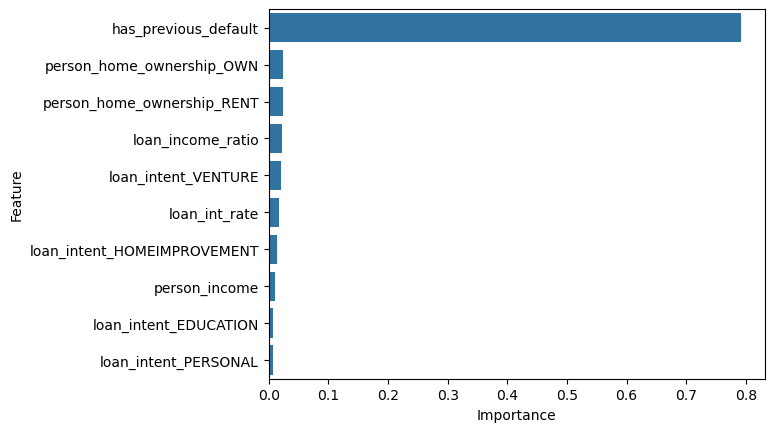

In [40]:
sns.barplot(data=top_features, x='Importance', y='Feature')
plt.show()

* Previous loan defaults are the strongest predictor of loan status. Other important factors include loan-to-income ratio, interest rate, income, home ownership, and loan purpose.
* Applicants with a history of previous loan defaults should be subject to stricter risk assessment, as past repayment behavior is the strongest indicator of future default risk.